<a href="https://colab.research.google.com/github/Pranayshukla0610/Recurrent_Neural_Network_-RNN-/blob/main/Stock_Price_Forecasting_Using_Recurrent_Neural_Networks_(RNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = yf.download(
    "AAPL",
    start = '2016-01-01',
    end = '2026-06-01'
)

/tmp/ipykernel_578/1987520842.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-01-04,23.709101,23.713603,22.955181,23.092462,270597600
2016-01-05,23.114967,23.821627,23.047453,23.799122,223164000
2016-01-06,22.662617,23.038453,22.475826,22.631110,273829600
2016-01-07,21.706150,22.534337,21.701650,22.208014,324377600
2016-01-08,21.820923,22.304782,21.775913,22.178754,283192000


In [5]:
data = df[['Close']]
data.head()

Price,Close
Ticker,AAPL
Date,
2016-01-04,23.709101
2016-01-05,23.114967
2016-01-06,22.662617
2016-01-07,21.706150
2016-01-08,21.820923


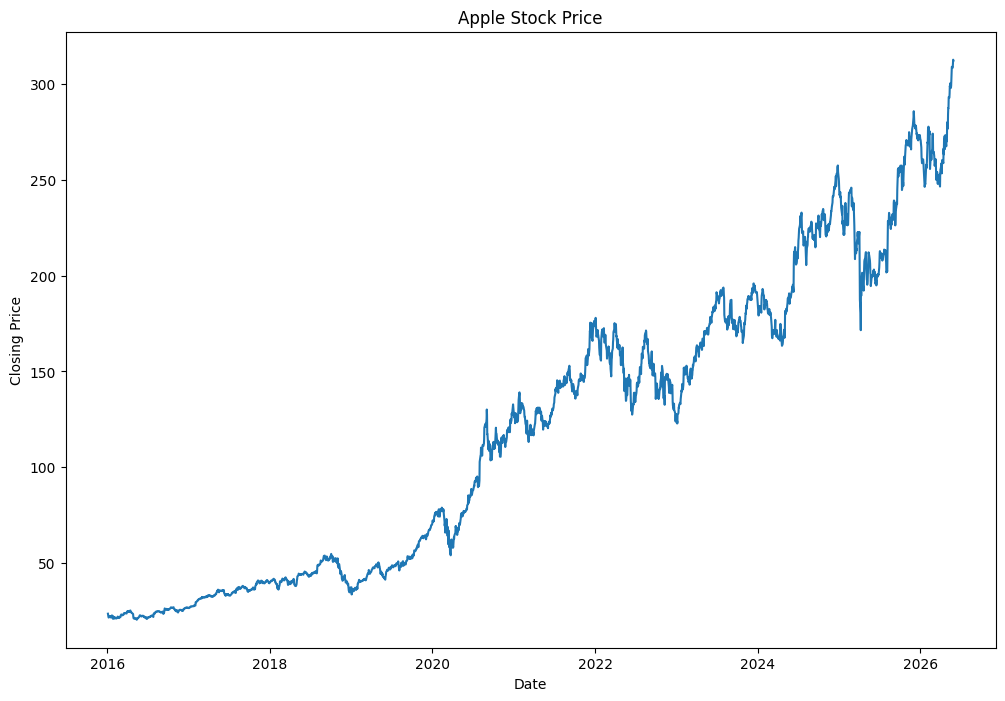

In [6]:
plt.figure(figsize=(12,8))
plt.plot(data)
plt.title('Apple Stock Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

In [7]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

In [8]:
def create_dataset(dataset, time_step=60):
  X = []
  y = []

  for i in range(len(dataset) - time_step):
    X.append(dataset[i:(i+time_step),0])
    y.append(dataset[i+time_step,0])

  return np.array(X), np.array(y)

In [9]:
X, y = create_dataset(
    scaled,
    60
)

In [10]:
print(X.shape)
print(y.shape)

(2556, 60)
(2556,)


In [11]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [12]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)


In [13]:
print(X_train.shape)
print(X_test.shape)

(2044, 60, 1)
(512, 60, 1)


In [14]:
model = Sequential()

model.add(
    SimpleRNN(
        50,
        activation='tanh',
        input_shape=(60,1)
    )
)

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.compile(
    optimizer='adam',
    loss = 'mse'
)

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0036 - val_loss: 0.0027
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.2885e-04 - val_loss: 0.0015
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.6036e-04 - val_loss: 1.9109e-04
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2032e-04 - val_loss: 3.5476e-04
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0013e-04 - val_loss: 3.4611e-04
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.6668e-05 - val_loss: 1.9115e-04
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.6328e-05 - val_loss: 1.6414e-04
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.1845e-05 - val_loss: 1.6700e-04
Epoch 9/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.3467e-05 - val_loss: 1.9064e-04
Epoch 10/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.8210e-05 - val_loss: 1.3044e-04
Epoch 11/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.2807e-05 - val_loss: 1.2848e-

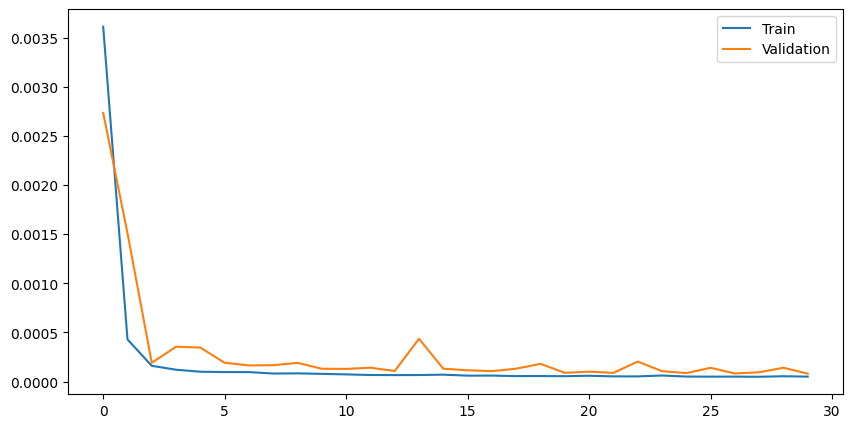

In [18]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend([
    "Train",
    "Validation"
])

plt.show()

In [19]:
predictions = model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


In [20]:
predictions = scaler.inverse_transform(
    predictions
)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [21]:
rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

print("RMSE:",rmse)

RMSE: 5.811343874641643


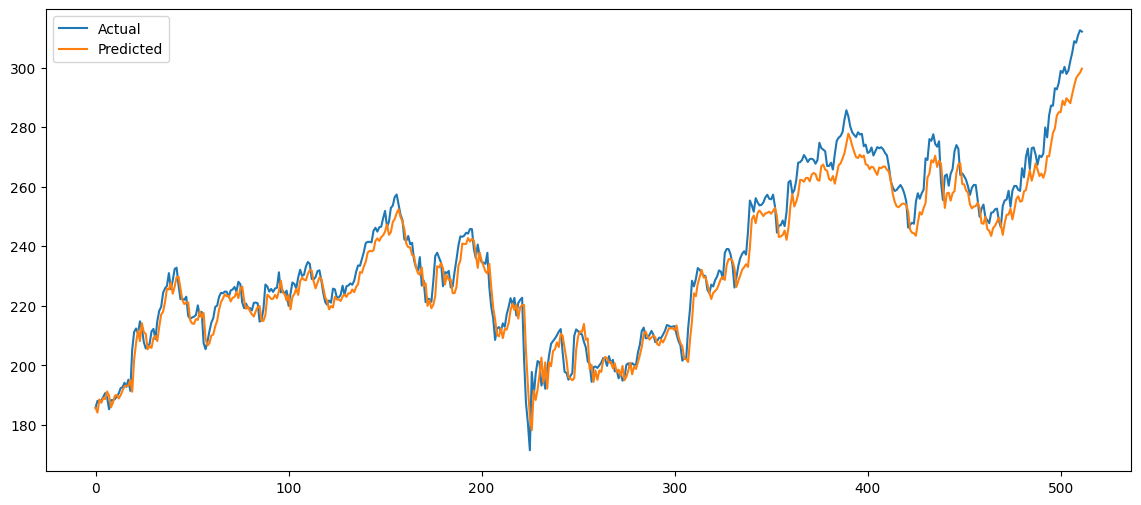

In [22]:
plt.figure(figsize=(14,6))

plt.plot(
    actual,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.legend()

plt.show()

In [24]:
last_60_days = scaled[-60:]

In [25]:
future = []

current = last_60_days.reshape(1,60,1)

for i in range(30):
  pred = model.predict(
      current,
      verbose=0
  )

  future.append(
      pred[0][0]
  )

  current = np.append(
      current[:,1:,:],
      [[[pred[0][0]]]],
      axis=1
  )

In [26]:
future_prices = scaler.inverse_transform(
    np.array(future).reshape(-1,1)
)

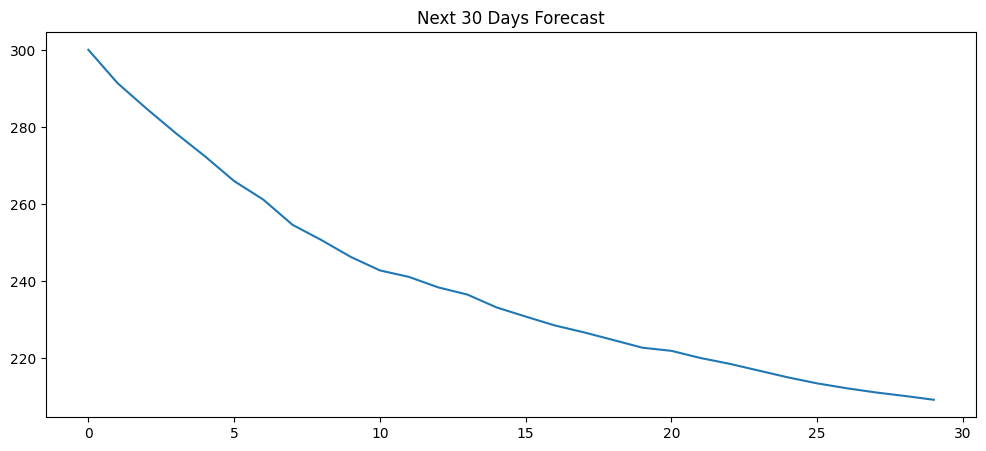

In [27]:
plt.figure(figsize=(12,5))

plt.plot(
    future_prices
)

plt.title(
    "Next 30 Days Forecast"
)

plt.show()